In [14]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

import numpy as np
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, \
    TimeSeriesResampler
import seaborn as sns
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import silhouette_score

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score 
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import sklearn.cluster

import os
from yellowbrick.cluster import SilhouetteVisualizer

import math
import scipy

from sklearn.metrics import adjusted_rand_score
from tslearn.metrics import soft_dtw

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Visualization Function

In [10]:
def ts_cluster_visualization(y_pred, df, n_clusters, plot_title):
    ts_size = df.shape[1]
    ts_max = df.max()
    plt.figure()
    for cluster in range(n_clusters):
        plt.subplot(4, math.ceil(n_clusters/4), cluster+1)
        for ts in df[y_pred == cluster]:
            plt.plot(ts.ravel(), "k-", alpha=.2)
        plt.plot(np.mean(df[y_pred == cluster], axis=0), "r-")
        plt.xlim(0, ts_size)
        plt.ylim(0, ts_max)
        plt.text(0.55, 0.35,'Cluster %d' % (cluster),
                 transform=plt.gca().transAxes)
        if cluster == 1:
            plt.title(plot_title)      
    plt.tight_layout()
    plt.show()

## Distance Function

In [11]:
def ts_cluster_distance(y_pred, df1, df2, df3, n_clusters, distance_measure, gamma=1.0):
    distances = []

    for cluster in range(n_clusters):
        mask = (y_pred == cluster)
        if not np.any(mask):
            continue  # skip empty clusters

        # cluster centers
        c1 = np.mean(df1[mask], axis=0)
        c2 = np.mean(df2[mask], axis=0)
        c3 = np.mean(df3[mask], axis=0)

        if distance_measure == "Euclidean":
            for ts1, ts2, ts3 in zip(df1[mask], df2[mask], df3[mask]):
                diff = np.sqrt(
                    np.sum((ts1.ravel() - c1) ** 2) +
                    np.sum((ts2.ravel() - c2) ** 2) +
                    np.sum((ts3.ravel() - c3) ** 2)
                )
                distances.append(diff)

        elif distance_measure == "SoftDTW":
            for ts1, ts2, ts3 in zip(df1[mask], df2[mask], df3[mask]):
                d1 = soft_dtw(ts1.reshape(-1, 1), c1.reshape(-1, 1), gamma=gamma)
                d2 = soft_dtw(ts2.reshape(-1, 1), c2.reshape(-1, 1), gamma=gamma)
                d3 = soft_dtw(ts3.reshape(-1, 1), c3.reshape(-1, 1), gamma=gamma)
                diff = np.sqrt(d1**2 + d2**2 + d3**2)  # combine like Euclidean norm
                distances.append(diff)

        else:
            raise ValueError("Unsupported distance measure: choose 'Euclidean' or 'SoftDTW'")

    return np.mean(distances)

# Baselines

In [15]:
poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
middle = pd.read_csv("SimData/bank_reserves_outputs_middle.csv", header=None)
rich = pd.read_csv("SimData/bank_reserves_outputs_rich.csv", header=None)

combined = pd.concat([poor, middle, rich], axis=1)
combined = StandardScaler().fit_transform(combined)

k = 7   
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(combined)

br_poor_ts = to_time_series_dataset(poor)
br_middle_ts = to_time_series_dataset(middle)
br_rich_ts = to_time_series_dataset(rich)

distance_br_no_FE = ts_cluster_distance(labels, br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")

C:\Users\met48\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\met48\AppData\Local\anaconda3\Lib\subprocess.py",

In [16]:
distance_br_no_FE

8313.86135471687

## Bank Reserves

In [17]:
label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_poor = pd.read_csv("SimData/bank_reserves_outputs_poor.csv", header=None)
br_poor_ts = to_time_series_dataset(br_poor)

label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_middle = pd.read_csv("SimData/bank_reserves_outputs_middle.csv", header=None)
br_middle_ts = to_time_series_dataset(br_middle)

label_results = pd.read_csv('bank_reserves_results.csv', index_col=0)
br_rich = pd.read_csv("SimData/bank_reserves_outputs_rich.csv", header=None)
br_rich_ts = to_time_series_dataset(br_rich)

In [18]:
distance_br_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")
distance_br_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")
distance_br_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")

distance_br_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")
distance_br_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")
distance_br_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")

distance_br_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")
distance_br_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")
distance_br_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), br_poor_ts, br_middle_ts, br_rich_ts, 7, "SoftDTW")

In [19]:
br_results_poor_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_br_pca_kmeans, distance_br_pca_agglom, distance_br_pca_spectral, 
              distance_br_dae_kmeans, distance_br_dae_agglom, distance_br_dae_spectral,
              distance_br_dcae_kmeans, distance_br_dcae_agglom, distance_br_dcae_spectral]
})

In [20]:
br_results_poor_df['Value'] = br_results_poor_df['Value'].apply(lambda x: x/8313.86135471687)

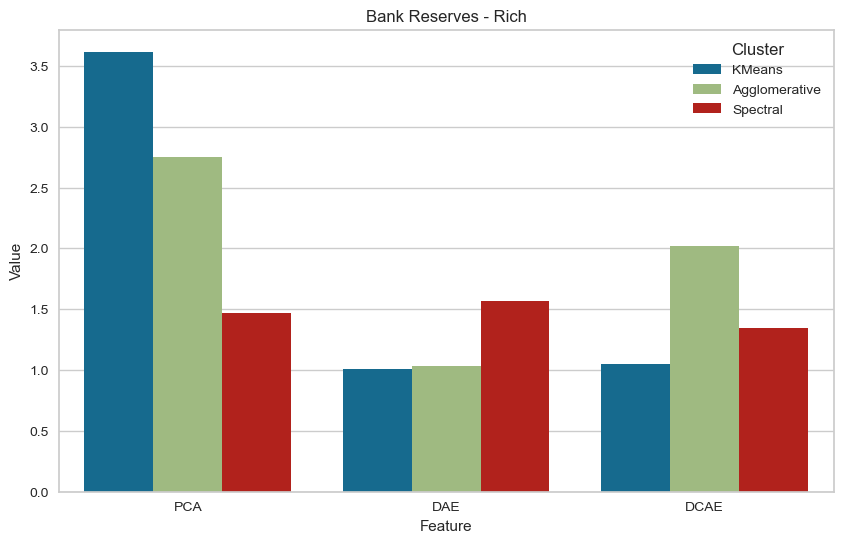

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(data=br_results_poor_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Bank Reserves - Rich")
plt.legend(title="Cluster")
#plt.ylim(3800, 4300)
plt.savefig("bank_reserves_rich_overall_norm.png", format="png")
plt.show()

# Epstein

In [24]:
label_results = pd.read_csv('epstein_results.csv', index_col=0)
ecv_active = pd.read_csv("SimData/epsteinCV_outputs_active.csv", header=None)
ecv_active_ts = to_time_series_dataset(ecv_active)

In [25]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_active_ts, 8, "SoftDTW")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_active_ts, 8, "SoftDTW")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_active_ts, 8, "SoftDTW")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_active_ts, 8, "SoftDTW")

In [26]:
ecv_results_active_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [27]:
ecv_jailed = pd.read_csv("SimData/epsteinCV_outputs_jailed.csv", header=None)
ecv_jailed_ts = to_time_series_dataset(ecv_jailed)

In [28]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_jailed_ts, 8, "SoftDTW")

In [29]:
ecv_results_jailed_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [30]:
ecv_quiet = pd.read_csv("SimData/epsteinCV_outputs_quiet.csv", header=None)
ecv_quiet_ts = to_time_series_dataset(ecv_quiet)

In [31]:
distance_ecv_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")

distance_ecv_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")

distance_ecv_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")
distance_ecv_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ecv_quiet_ts, 8, "SoftDTW")

In [32]:
ecv_results_quiet_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ecv_pca_kmeans, distance_ecv_pca_agglom, distance_ecv_pca_spectral, 
              distance_ecv_dae_kmeans, distance_ecv_dae_agglom, distance_ecv_dae_spectral,
              distance_ecv_dcae_kmeans, distance_ecv_dcae_agglom, distance_ecv_dcae_spectral]
})

In [33]:
ecv_results_active_df['Value'] = ecv_results_active_df['Value'].apply(lambda x: x/1662447.0778391678)
ecv_results_jailed_df['Value'] = ecv_results_jailed_df['Value'].apply(lambda x: x/935593.2755125551)
ecv_results_quiet_df['Value'] = ecv_results_quiet_df['Value'].apply(lambda x: x/3051922.3458011313)

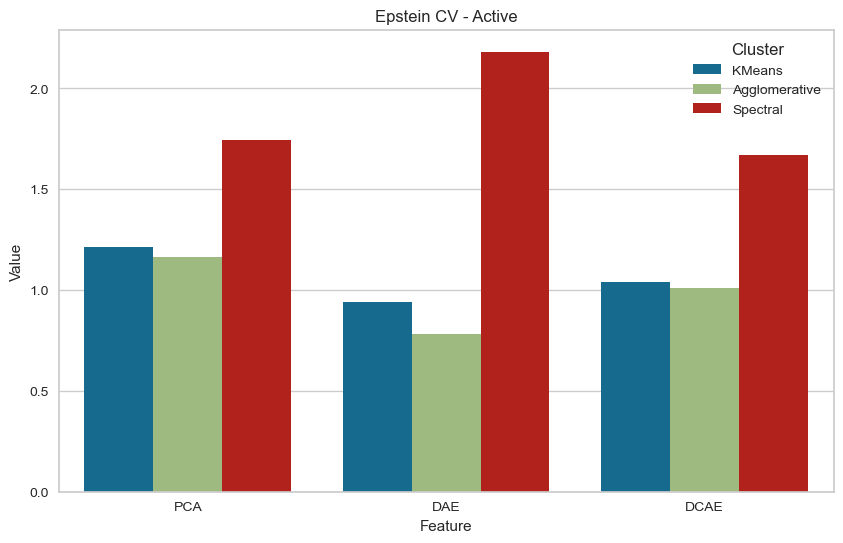

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_active_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Active")
plt.legend(title="Cluster")
#plt.ylim(10000, 20000)
plt.savefig("epstein_active_overall_norm.png", format="png")
plt.show()

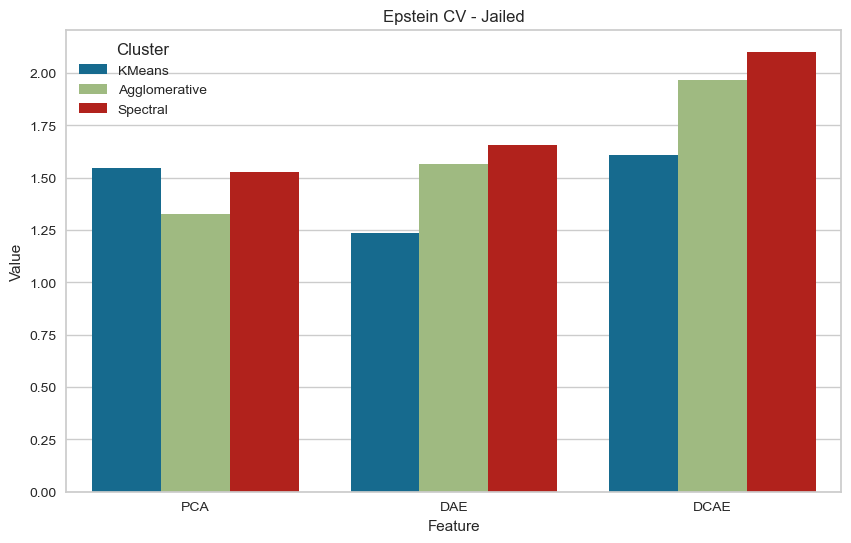

In [35]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_jailed_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Jailed")
plt.legend(title="Cluster")
#plt.ylim(10000, 25000)
plt.savefig("epstein_jailed_overall_norm.png", format="png")
plt.show()

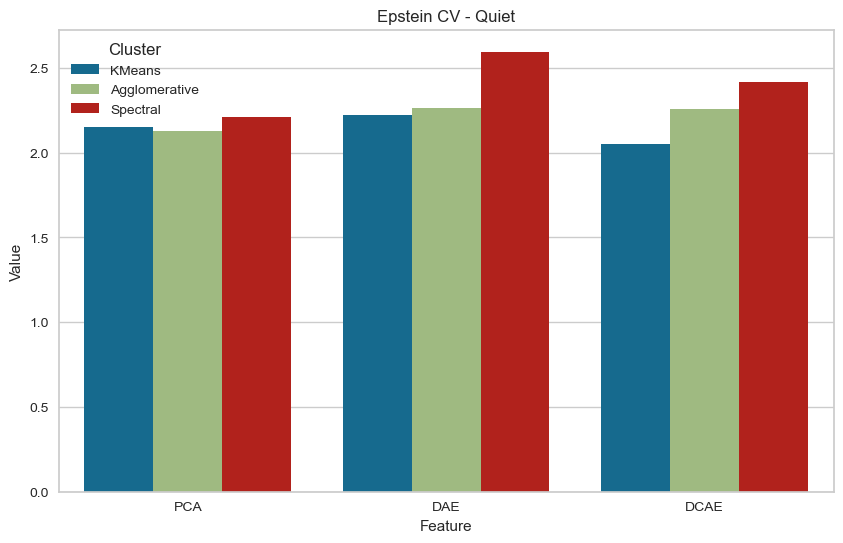

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ecv_results_quiet_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Epstein CV - Quiet")
plt.legend(title="Cluster")
#plt.ylim(15000, 45000)
plt.savefig("epstein_quiet_overall_norm.png", format="png")
plt.show()

In [37]:
def import_ff_data(filename):
    expected_columns=155
    data = []
    with open(filename, 'r') as file:
        for line in file:
            row = line.strip().split(',')
            if len(row) < expected_columns:
                row += [np.nan] * (expected_columns - len(row))
            data.append(row)
    df = pd.DataFrame(data)
    def fill_last_valid(row):
        for i in range(1, len(row)):
            if pd.isna(row[i]):
                row[i] = row[i - 1]  
        return row
    df_filled = df.apply(fill_last_valid, axis=1)
    return df_filled

In [38]:
label_results = pd.read_csv('forestfire_results.csv', index_col=0)
ff_onfire = import_ff_data("SimData/forest_fire_outputs_onfire.csv")
ff_onfire_ts = to_time_series_dataset(ff_onfire)

In [39]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_onfire_ts, 4, "SoftDTW")

In [40]:
ff_results_onfire_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [41]:
ff_fine = import_ff_data("SimData/forest_fire_outputs_fine.csv")
ff_fine_ts = to_time_series_dataset(ff_fine)

In [42]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_fine_ts, 4, "SoftDTW")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_fine_ts, 4, "SoftDTW")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_fine_ts, 4, "SoftDTW")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_fine_ts, 4, "SoftDTW")

In [43]:
ff_results_fine_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [44]:
ff_burned = import_ff_data("SimData/forest_fire_outputs_burned.csv")
ff_burned_ts = to_time_series_dataset(ff_burned)

In [45]:
distance_ff_pca_kmeans = ts_cluster_distance(label_results.loc["PCA_KMeans"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_pca_agglom = ts_cluster_distance(label_results.loc["PCA_Agglom"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_pca_spectral = ts_cluster_distance(label_results.loc["PCA_Spectral"].to_numpy(), ff_burned_ts, 4, "SoftDTW")

distance_ff_dae_kmeans = ts_cluster_distance(label_results.loc["DAE_KMeans"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dae_agglom = ts_cluster_distance(label_results.loc["DAE_Agglom"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dae_spectral = ts_cluster_distance(label_results.loc["DAE_Spectral"].to_numpy(), ff_burned_ts, 4, "SoftDTW")

distance_ff_dcae_kmeans = ts_cluster_distance(label_results.loc["DCAE_KMeans"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dcae_agglom = ts_cluster_distance(label_results.loc["DCAE_Agglom"].to_numpy(), ff_burned_ts, 4, "SoftDTW")
distance_ff_dcae_spectral = ts_cluster_distance(label_results.loc["DCAE_Spectral"].to_numpy(), ff_burned_ts, 4, "SoftDTW")

In [46]:
ff_results_burned_df = pd.DataFrame({
    "Feature": ["PCA", "PCA", "PCA", "DAE", "DAE", "DAE", "DCAE", "DCAE", "DCAE"],
    "Cluster": ["KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral", "KMeans", "Agglomerative", "Spectral"],
    "Value": [distance_ff_pca_kmeans, distance_ff_pca_agglom, distance_ff_pca_spectral, 
              distance_ff_dae_kmeans, distance_ff_dae_agglom, distance_ff_dae_spectral,
              distance_ff_dcae_kmeans, distance_ff_dcae_agglom, distance_ff_dcae_spectral]
})

In [47]:
ff_results_onfire_df['Value'] = ff_results_onfire_df['Value'].apply(lambda x: x/17640.456365358114)
ff_results_fine_df['Value'] = ff_results_fine_df['Value'].apply(lambda x: x/18933952.852686398)
ff_results_burned_df['Value'] = ff_results_burned_df['Value'].apply(lambda x: x/80475845.29474212)

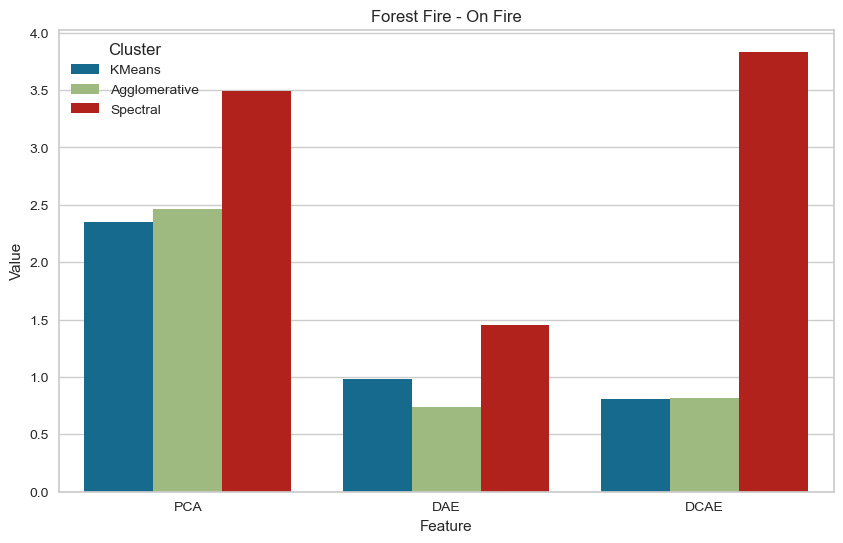

In [48]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_onfire_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - On Fire")
plt.legend(title="Cluster")
#plt.ylim(5000, 8000)
plt.savefig("ff_onfire_overall_norm.png", format="png")
plt.show()

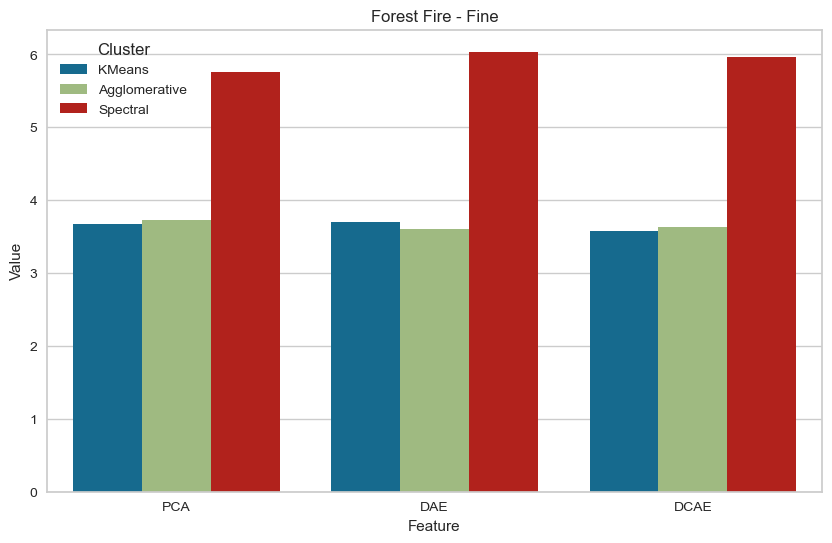

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_fine_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - Fine")
plt.legend(title="Cluster")
#plt.ylim(200000, 290000)
plt.savefig("ff_fine_overall_norm.png", format="png")
plt.show()

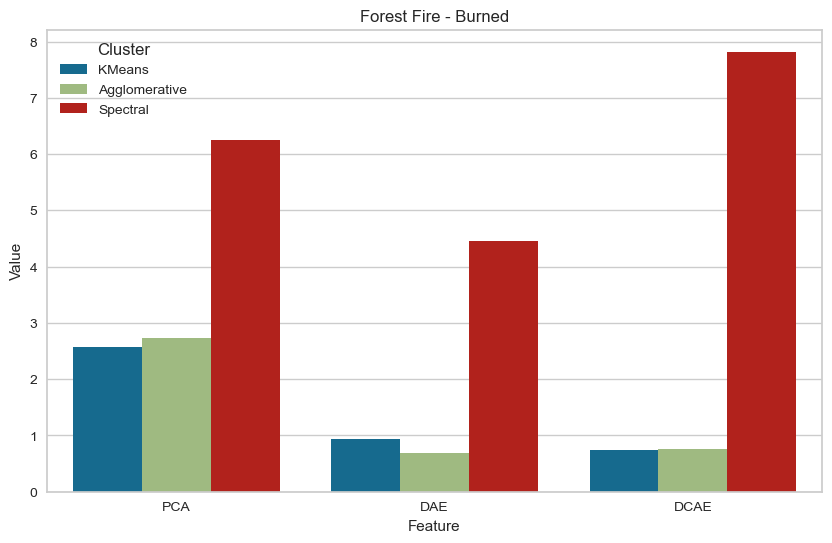

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(data=ff_results_burned_df, x="Feature", y="Value", hue="Cluster")

# Customize the plot
plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Forest Fire - Burned")
plt.legend(title="Cluster")
#plt.ylim(200000, 350000)
plt.savefig("ff_burned_overall_norm.png", format="png")
plt.show()